# Cell 0 Kiểm tra GPU

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

2.3.1+cu121
True
NVIDIA GeForce RTX 3050 Laptop GPU
3.99951171875 GB


# Cell 1 Đọc dataset từ Kaggle

In [4]:
import os

BASE      = r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET"
TRAIN_DIR = os.path.join(BASE, "TRAIN")
TEST_DIR  = os.path.join(BASE, "TEST")

print("TRAIN:", TRAIN_DIR, "->", os.path.exists(TRAIN_DIR))
print("TEST :", TEST_DIR,  "->", os.path.exists(TEST_DIR))

TRAIN: D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET\TRAIN -> True
TEST : D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET\TEST -> True


# Cell 2 In cấu trúc folder

In [5]:
data_dir = r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data"

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{'  ' * (level+1)}{f}")

data/
  DATASET/
    DATASET/
      TEST/
        O/
        R/
      TRAIN/
        O/
        R/
    TEST/
      O/
      R/
    TRAIN/
      O/
      R/


# Cell 2.1 Tinh chỉnh đường dẫn TRAIN/TEST

In [6]:
BASE = r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET"
TRAIN_DIR = os.path.join(BASE, "TRAIN")
TEST_DIR  = os.path.join(BASE, "TEST")

print("TRAIN:", TRAIN_DIR, "->", os.path.exists(TRAIN_DIR))
print("TEST: ", TEST_DIR,  "->", os.path.exists(TEST_DIR))

TRAIN: D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET\TRAIN -> True
TEST:  D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\data\DATASET\TEST -> True


# Cell 3 Kiểm tra số lượng ảnh và class

In [7]:
for split, path in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"\n{split}:")
    total = 0
    for cls in sorted(os.listdir(path)):
        n = len(os.listdir(os.path.join(path, cls)))
        print(f"  {cls}: {n}")
        total += n
    print(f"  Total: {total}")


TRAIN:
  O: 12565
  R: 9999
  Total: 22564

TEST:
  O: 1401
  R: 1112
  Total: 2513


# Cell 4 Khám phá dữ liệu

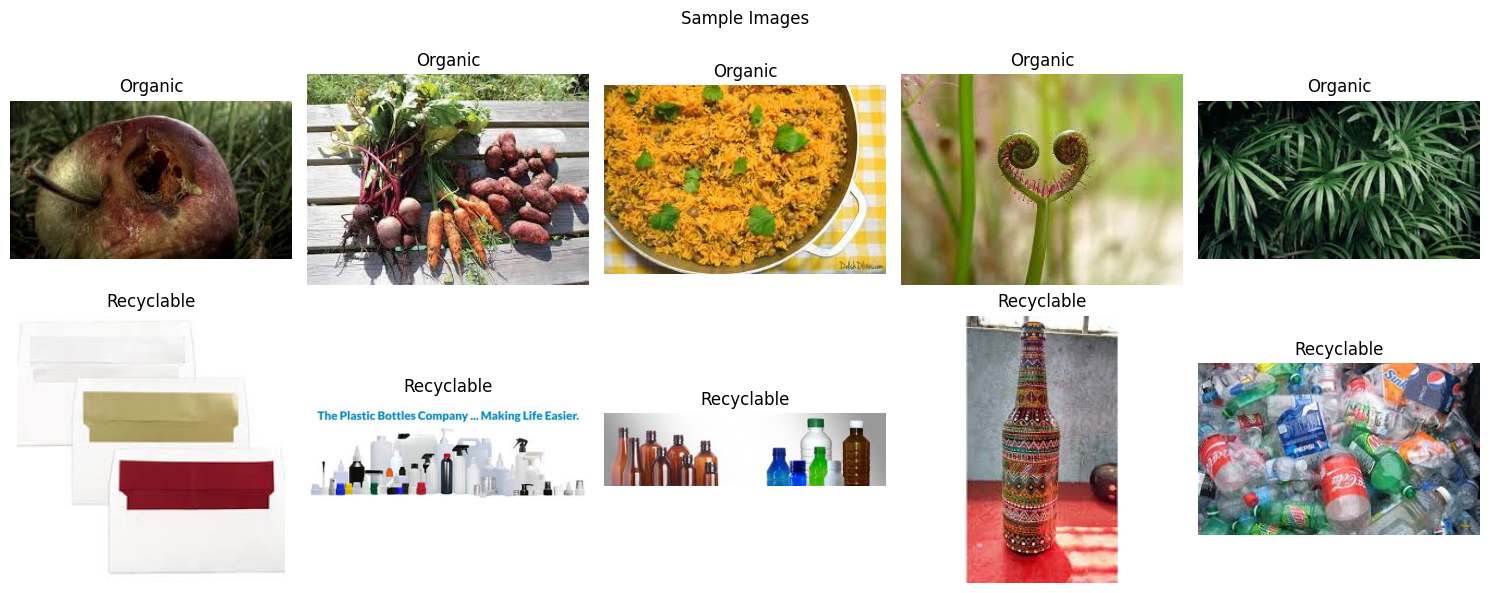

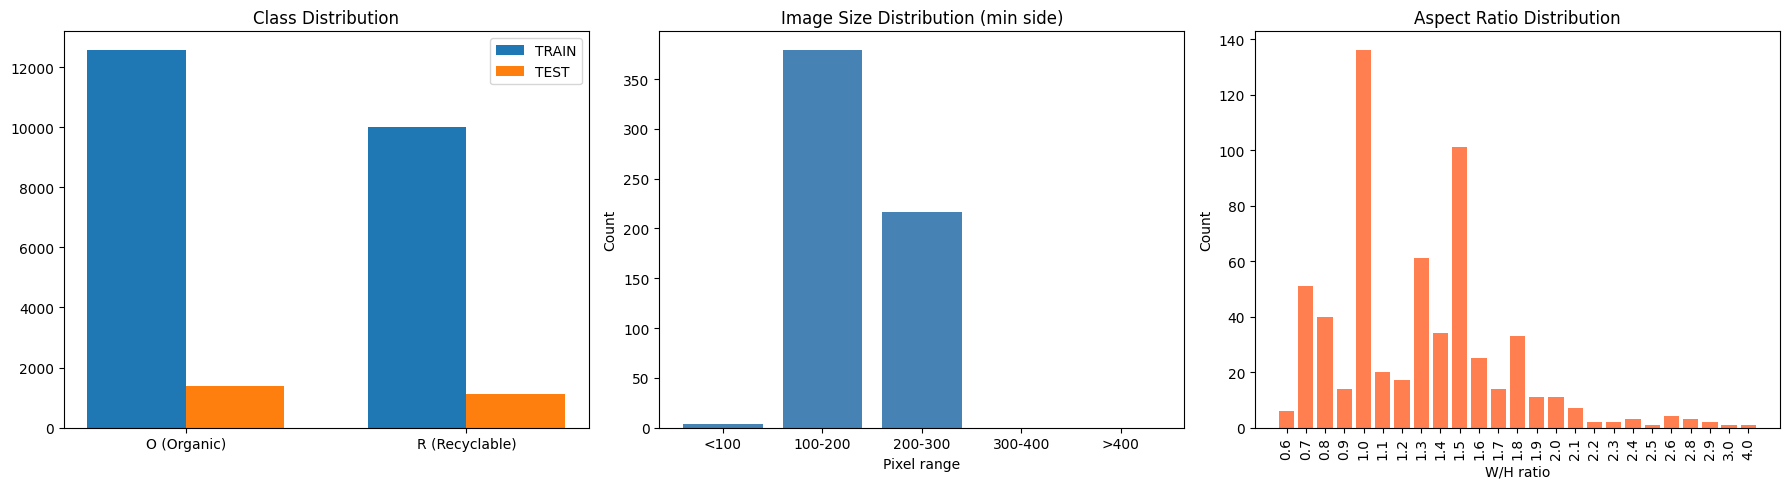

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

# --- Sample Images ---
fig2, ax2 = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(["O", "R"]):
    imgs = random.sample(os.listdir(os.path.join(TRAIN_DIR, cls)), 5)
    for j, fname in enumerate(imgs):
        img = Image.open(os.path.join(TRAIN_DIR, cls, fname)).convert("RGB")
        ax2[i][j].imshow(img)
        ax2[i][j].set_title("Organic" if cls=="O" else "Recyclable")
        ax2[i][j].axis("off")
plt.suptitle("Sample Images"); plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\samples.png")
plt.show()

# --- Class Distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = {"TRAIN": {"O": 12565, "R": 9999}, "TEST": {"O": 1401, "R": 1112}}
x = np.arange(2); w = 0.35
axes[0].bar(x - w/2, list(splits["TRAIN"].values()), w, label="TRAIN")
axes[0].bar(x + w/2, list(splits["TEST"].values()),  w, label="TEST")
axes[0].set_xticks(x); axes[0].set_xticklabels(["O (Organic)", "R (Recyclable)"])
axes[0].legend(); axes[0].set_title("Class Distribution")

# --- Size Distribution (bar chart) ---
size_buckets = {"<100": 0, "100-200": 0, "200-300": 0, "300-400": 0, ">400": 0}
for cls in ["O", "R"]:
    files = random.sample(os.listdir(os.path.join(TRAIN_DIR, cls)), 300)
    for f in files:
        w_img, h_img = Image.open(os.path.join(TRAIN_DIR, cls, f)).size
        side = min(w_img, h_img)
        if side < 100: size_buckets["<100"] += 1
        elif side < 200: size_buckets["100-200"] += 1
        elif side < 300: size_buckets["200-300"] += 1
        elif side < 400: size_buckets["300-400"] += 1
        else: size_buckets[">400"] += 1

axes[1].bar(size_buckets.keys(), size_buckets.values(), color="steelblue")
axes[1].set_title("Image Size Distribution (min side)")
axes[1].set_xlabel("Pixel range"); axes[1].set_ylabel("Count")

# --- Aspect Ratio Distribution ---
ratios = []
for cls in ["O", "R"]:
    files = random.sample(os.listdir(os.path.join(TRAIN_DIR, cls)), 300)
    for f in files:
        w_img, h_img = Image.open(os.path.join(TRAIN_DIR, cls, f)).size
        ratios.append(round(w_img / h_img, 1))
unique, counts = np.unique(ratios, return_counts=True)
axes[2].bar(unique.astype(str), counts, color="coral")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("W/H ratio"); axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\distribution.png")
plt.show()

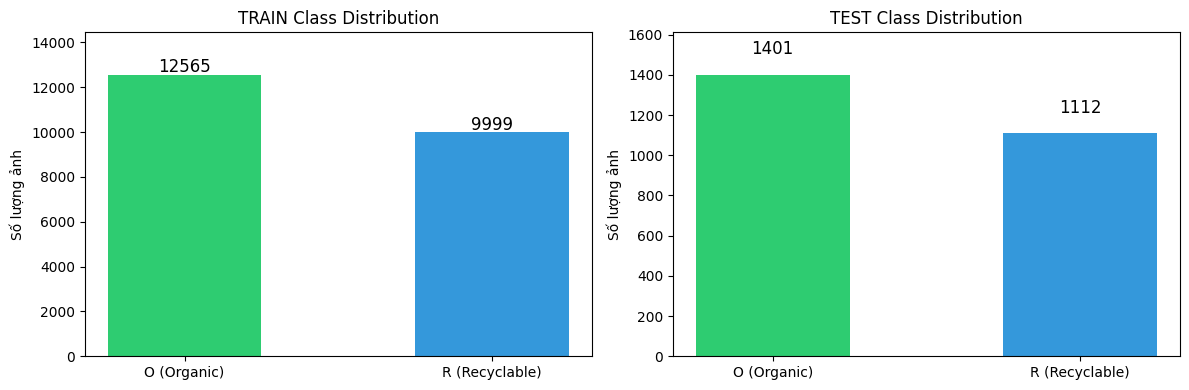

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split, counts) in zip(axes, [("TRAIN", {"O":12565,"R":9999}), ("TEST", {"O":1401,"R":1112})]):
    bars = ax.bar(["O (Organic)", "R (Recyclable)"], counts.values(), color=["#2ecc71","#3498db"], width=0.5)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(val), ha="center", fontsize=12)
    ax.set_title(f"{split} Class Distribution")
    ax.set_ylabel("Số lượng ảnh")
    ax.set_ylim(0, max(counts.values()) * 1.15)

plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\class_distribution.png")
plt.show()

# Cell 5 Tiền xử lý + DataLoader

In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 4
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset), "| Test:", len(test_dataset))
print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))

Classes: ['O', 'R']
Train: 22564 | Test: 2513
Train batches: 706 | Test batches: 79


# Cell 6 Siêu tham số 

In [15]:
CONFIG = {
    "model"        : "resnet50",
    "pretrained"   : True,
    "num_classes"  : 2,
    "img_size"     : 224,
    "batch_size"   : 32,
    "epochs"       : 15,
    "lr"           : 1e-4,
    "weight_decay" : 1e-4,
    "optimizer"    : "AdamW",
    "scheduler"    : "CosineAnnealingLR",
    "T_max"        : 30,
    "eta_min"      : 1e-6,
    "early_stop"   : 5,
    "unfreeze_epoch": 5,
}

for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

  model               : resnet50
  pretrained          : True
  num_classes         : 2
  img_size            : 224
  batch_size          : 32
  epochs              : 15
  lr                  : 0.0001
  weight_decay        : 0.0001
  optimizer           : AdamW
  scheduler           : CosineAnnealingLR
  T_max               : 30
  eta_min             : 1e-06
  early_stop          : 5
  unfreeze_epoch      : 5


# Cell 7 Cấu hình

In [16]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, CONFIG["num_classes"])
)
model = model.to(DEVICE)

# Class weights (imbalance O vs R)
class_counts = torch.tensor([12565, 9999], dtype=torch.float)
class_weights = (1.0 / class_counts)
class_weights = (class_weights / class_weights.sum()).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.fc.parameters(),
                               lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["T_max"], eta_min=CONFIG["eta_min"])

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, path="best_model.pth"):
        self.patience = patience; self.counter = 0
        self.best_score = None; self.path = path
    def __call__(self, val_loss, model):
        if self.best_score is None or val_loss < self.best_score:
            self.best_score = val_loss; self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
        return self.counter >= self.patience

CKPT_PATH = r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\models\best_model.pth"
early_stopping = EarlyStopping(patience=CONFIG["early_stop"], path=CKPT_PATH)

print("Model ready on:", DEVICE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [02:14<00:00, 761kB/s] 


Model ready on: cuda
Trainable params: 4098


# Cell 8 Huấn luyện mô hình

In [ ]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[],
           "train_auc":[], "val_auc":[], "train_f1":[], "val_f1":[]}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, all_labels, all_probs = 0, 0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training: optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            probs = torch.softmax(outputs, dim=1)[:,1].detach().cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.cpu().numpy())
    n = len(loader.dataset)
    avg_loss = total_loss / n
    acc = correct / n
    auc = roc_auc_score(all_labels, all_probs)
    f1  = f1_score(all_labels, [1 if p > 0.5 else 0 for p in all_probs], average="weighted")
    return avg_loss, acc, auc, f1

for epoch in range(1, CONFIG["epochs"] + 1):
    # Unfreeze toàn bộ sau epoch unfreeze_epoch
    if epoch == CONFIG["unfreeze_epoch"]:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(),
                                       lr=CONFIG["lr"]/10, weight_decay=CONFIG["weight_decay"])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["T_max"], eta_min=CONFIG["eta_min"])
        print(f">> Unfrozen all layers at epoch {epoch}")

    tr_loss, tr_acc, tr_auc, tr_f1 = run_epoch(train_loader, training=True)
    vl_loss, vl_acc, vl_auc, vl_f1 = run_epoch(test_loader,  training=False)
    scheduler.step()

    for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc,
                                       tr_auc, vl_auc, tr_f1, vl_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.4f}/{vl_acc:.4f} | "
          f"AUC {tr_auc:.4f}/{vl_auc:.4f} | "
          f"F1 {tr_f1:.4f}/{vl_f1:.4f}")

    if early_stopping(vl_loss, model):
        print("Early stopping triggered."); break

print("Training complete. Best model saved.")

# Cell 9 Đánh giá

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score
import seaborn as sns
import numpy as np
import torch

# Load best model
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print("Test Accuracy :", (all_labels == all_preds).mean())
print("Test AUC      :", roc_auc_score(all_labels, all_probs))
print("Test F1       :", f1_score(all_labels, all_preds, average="weighted"))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Organic","Recyclable"]))

# Confusion Matrix
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Organic","Recyclable"],
            yticklabels=["Organic","Recyclable"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Loss curve
axes[1].plot(history["train_loss"], label="Train")
axes[1].plot(history["val_loss"],   label="Val")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")

# Accuracy curve
axes[2].plot(history["train_acc"], label="Train")
axes[2].plot(history["val_acc"],   label="Val")
axes[2].set_title("Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

# AUC curve
axes[3].plot(history["train_auc"], label="Train")
axes[3].plot(history["val_auc"],   label="Val")
axes[3].set_title("AUC"); axes[3].legend(); axes[3].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\eval_curves.png")
plt.show()

# F1 curve (riêng)
fig2, ax = plt.subplots(figsize=(6, 4))
ax.plot(history["train_f1"], label="Train")
ax.plot(history["val_f1"],   label="Val")
ax.set_title("F1-Score"); ax.legend(); ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\f1_curve.png")
plt.show()

# Cell 10 Dự đoán 10 ảnh

In [ ]:
import random
from PIL import Image

CLASS_NAMES = {0: "Organic", 1: "Recyclable"}
model.eval()

samples = []
for cls_idx, cls_folder in [(0, "O"), (1, "R")]:
    files = random.sample(os.listdir(os.path.join(TEST_DIR, cls_folder)), 5)
    for f in files:
        samples.append((os.path.join(TEST_DIR, cls_folder, f), cls_idx))
random.shuffle(samples)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, (img_path, true_label) in enumerate(samples):
    img_pil = Image.open(img_path).convert("RGB")
    tensor  = test_transforms(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred   = int(np.argmax(probs))
    ax = axes[i // 5][i % 5]
    ax.imshow(img_pil)
    color = "green" if pred == true_label else "red"
    ax.set_title(
        f"True : {CLASS_NAMES[true_label]}\n"
        f"Pred : {CLASS_NAMES[pred]}\n"
        f"O:{probs[0]*100:.1f}%  R:{probs[1]*100:.1f}%",
        fontsize=9, color=color
    )
    ax.axis("off")

plt.suptitle("Random 10 Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.savefig(r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\outputs\predictions.png")
plt.show()

# Cell 11 Lưu mô hình

In [ ]:
import json

MODEL_DIR = r"D:\Documents\HK2 2025-26 KHDL (Y3) Ky 6\BigData\waste-classification\models"

# Lưu full model info
torch.save({
    "model_state_dict" : model.state_dict(),
    "class_to_idx"     : train_dataset.class_to_idx,
    "config"           : CONFIG,
}, os.path.join(MODEL_DIR, "resnet50_waste.pth"))

# Lưu class mapping
with open(os.path.join(MODEL_DIR, "class_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"O": "Hữu cơ", "R": "Tái chế"}, f, ensure_ascii=False)

print("Saved:", os.path.join(MODEL_DIR, "resnet50_waste.pth"))
print("Size :", round(os.path.getsize(os.path.join(MODEL_DIR, "resnet50_waste.pth")) / 1024**2, 2), "MB")